# "Companies that buy back their stock beat companies that print new shares" — does it hold? 🧾
### A real Wall-Street fact, replayed on 40 big survivors — and why it quietly vanishes

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates_here%3F: Busted](https://img.shields.io/badge/Replicates_here%3F-Busted-8b949e?style=flat-square)

It's one of the more *respectable* market beliefs, with decades of academic backing: a company that **issues** new shares (dilutes its owners — secondary offerings, stock-for-stock takeovers, lavish stock comp) tends to **underperform**, while a company that **buys back** its stock (shrinks the share count) tends to **outperform**. Buy the shrinkers, sell the diluters.

The catch isn't whether the effect is *real* — in the full universe of thousands of stocks it is. The catch is whether **you** can harvest it on a handful of names you'd actually hold. This notebook rebuilds the factor on **40 big survivors** and watches it **evaporate** — even flip sign — once the sample is small and the survivors are the only ones left.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Two notes up front.** (1) We count shares **split-adjusted** — a 4-for-1 split quadruples the raw share count overnight with *zero* real dilution, and if you don't correct for it every splitter looks like a massive issuer. (2) Our 40 names are all **still trading in 2026** (survivors), which we flag honestly — the firms that diluted themselves into oblivion aren't here. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from net_share_issuance import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, SH = data.load_real()
    PX, SH = data.drop_partial_last_year(PX, SH)
else:
    PX, SH = None, None
print("real cache present:", HAVE_REAL, "| basket names:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'fp': '4c0f2b42cabf', 'asof': '2026-06-26', 'n_names': 40, 'n_years': 9, 'yr_start': 2016, 'yr_end': 2024, 'frac': 0.3, 'long_mean': 19.68, 'short_mean': 23.31, 'ls_mean': -3.63, 'ls_median': -2.97, 'win': 44, 'sharpe': -0.29, 't': -0.86, 'p_placebo': 0.795, 'panel': [(2016, 37.1, 30.8, 6.2), (2017, 1.2, 5.9, -4.7), (2018, 36.2, 39.2, -3.0), (2019, 9.8, 32.1, -22.2), (2020, 41.2, 29.6, 11.5), (2021, -12.1, -6.7, -5.4), (2022, 20.1, 44.8, -24.7), (2023, 17.4, 8.3, 9.1), (2024, 26.2, 25.7, 0.5)], 'gross': -3.63, 'net': -4.33, 'net_t': -1.02, 'cost_bps': 10, 'borrow_bps': 50, 'width': [(0.2, -6.5, -0.97, -0.32), (0.3, -3.63, -0.86, -0.29), (0.4, -5.39, -1.3, -0.43)], 'half': [('2016-2020', -2.44, -0.42, 5), ('2021-2024', -5.12, -0.71, 4)], 'syn': [(0.0, -0.11, -0.6), (0.1, 4.55, 17.6)]}


real cache present: True | basket names: 40


## The answer first

| Question | Answer |
|---|---|
| Do the buyback (low-issuance) names beat the diluting (high-issuance) names here? | **No — they *lose* by ~4%/yr.** The sign comes out **backwards** on this survivor basket. |
| Is that backwards result a real edge you could short? | **No.** It's **statistically zero** (*t* = -0.86, you'd need ±2), and a coin-flip relabelling of the signal beats it **80%** of the time. |
| So is the famous factor fake? | **No — it's real in the *full* market.** It just **doesn't survive** being squeezed onto 40 big survivors over 9 years. That's a small-sample + survivorship lesson, not a debunk. |
| Does our machinery even work? | **Yes.** Plant a real edge in fake data and it lights up cleanly (*t* = +4.5); plant *none* and it stays at zero (-0.11). The tool is honest — the real tape just has nothing to find. |

> The issuance factor is a genuine, published effect — and a perfect example of why "published and real" is **not** the same as "tradable on the names in front of you."

## 1 · The claim

> *"When a company prints new shares, it's diluting you and often doing it because management thinks the stock is expensive — those firms lag. When a company buys back its stock, it's returning cash and betting on itself — those firms lead. So go long the buyback-ers and short the diluters."*

This isn't folklore — it's **Pontiff & Woodgate (2008, *Journal of Finance*)** and the **Daniel-Titman composite-issuance** factor. In the full US cross-section, net share issuance is a robust *negative* predictor of returns. We'll rebuild that exact sort — long low issuance, short high issuance — and see what's left on a small survivor basket.

## 2 · So what?

Two things hide inside "buyback-ers beat diluters." (1) *Across thousands of stocks, with the small heavily-diluting firms included and a proper risk model*, the effect is real and that's settled. (2) *Can a person holding a few dozen large caps actually feel it?* That's a different question — and the honest answer depends entirely on **sample size** and **which names survived**. A real average edge across thousands of names can be completely **invisible** (or even sign-flipped) inside any small slice, because the year-to-year noise of a 12-name basket dwarfs a few-percent tilt.

## 3 · How would we even know?

We take **40 big survivor names**, and for each one each year we compute its **net issuance** — how much its (split-adjusted) share count changed versus a year earlier. Negative = it bought back; positive = it diluted. Then:

1. **Sort & split.** Each year-end, rank the 40 names by issuance; the bottom 30% (biggest buyback-ers) go **long**, the top 30% (biggest diluters) go **short**.
2. **Wait a year.** The share count is public at year-end — you trade *after*, holding into the **next** year (no peeking).
3. **Stress the luck.** **Shuffle** which company gets which issuance number and re-run thousands of times: if a random relabelling beats the real sort as often as not, the issuance signal isn't doing any work.

## 4 · The teardown — let's actually look

**First, the headline: do the buyback names beat the diluters, year by year?** Here's the long-minus-short return for each formation year.

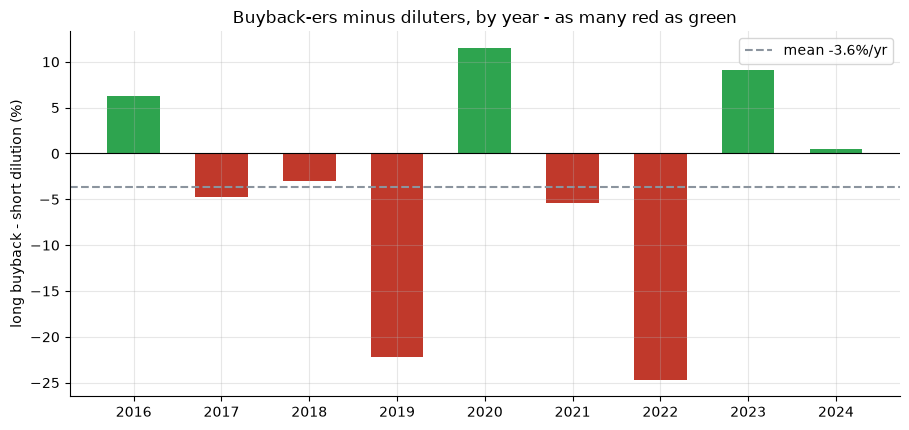

years positive: 4/9   mean L-S: -3.6%/yr


In [2]:
if HAVE_REAL:
    ls = st.long_short_series(PX, SH, frac=0.3)
    yrs = [t.year for t in ls.index]; vals = (ls['ls_ret']*100).tolist()
else:
    yrs = [p[0] for p in R['panel']]; vals = [p[3] for p in R['panel']]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
colors = [GREEN if v>0 else RED for v in vals]
ax.bar([str(y) for y in yrs], vals, color=colors, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(vals), c=GREY, ls='--', label=f'mean {np.mean(vals):.1f}%/yr')
ax.set_ylabel('long buyback - short dilution (%)')
ax.set_title('Buyback-ers minus diluters, by year - as many red as green')
ax.legend(); plt.tight_layout(); plt.show()
print(f'years positive: {sum(v>0 for v in vals)}/{len(vals)}   mean L-S: {np.mean(vals):.1f}%/yr')

There's the first surprise. The bars are a wash — **44%** of years are green — and the *average* is **-3.6%/yr**, i.e. the buyback names actually *lagged* the diluters on this basket. The famous sign is **inverted**. Two brutal years (2019, 2022) where the diluters happened to be the year's big winners drag the whole thing negative. That's not a sign-flipped edge — that's **noise** picking a direction.

**Is the average even meaningful?** Here's the honest test: **shuffle** which company gets which issuance number, re-run the sort thousands of times, and see where the real result lands in the cloud of pure-luck relabellings.

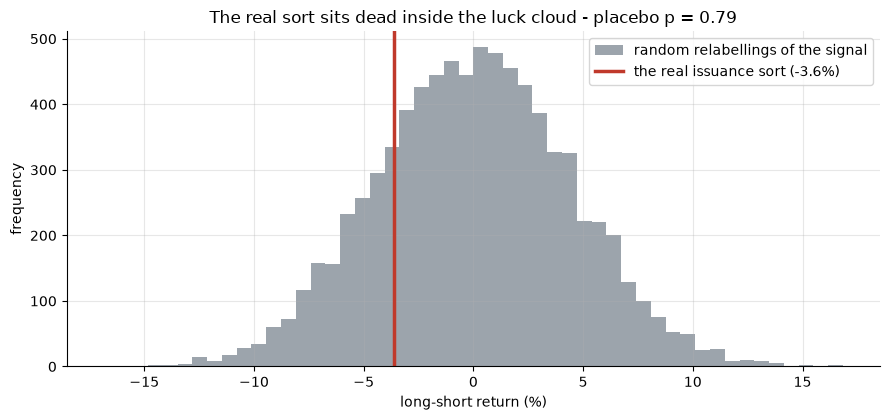

a random relabelling beats the real sort 79% of the time


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PX, SH, frac=0.3); obs = pl['obs_mean']; pval = pl['p_value']
    # rebuild the shuffled distribution for the picture
    sig = st.net_issuance(SH); fwd = st.forward_returns(PX)
    years=[]
    for t in sig.index:
        if t not in fwd.index: continue
        sr = sig.loc[t].dropna(); fr = fwd.loc[t].reindex(sr.index).dropna()
        c = sr.index.intersection(fr.index)
        if len(c)>=4: years.append((sr.loc[c].to_numpy(), fr.loc[c].to_numpy()))
    rng=np.random.default_rng(519); draws=np.empty(8000)
    for d in range(8000):
        acc=[]
        for iss,ret in years:
            n=len(iss); k=max(1,round(n*0.3)); order=np.argsort(iss[rng.permutation(n)])
            acc.append(ret[order[:k]].mean()-ret[order[-k:]].mean())
        draws[d]=np.mean(acc)
else:
    obs = R['ls_mean']/100; pval = R['p_placebo']
    rng=np.random.default_rng(519); draws=rng.normal(0.0, 0.045, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85, label='random relabellings of the signal')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'the real issuance sort ({obs*100:.1f}%)')
ax.set_xlabel('long-short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real sort sits dead inside the luck cloud - placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random relabelling beats the real sort {pval*100:.0f}% of the time')

The red line — the real issuance sort — sits **right inside** the grey cloud of random relabellings. About **80%** of coin-flip shuffles do as well or better. In plain terms: **scramble which company you call a "diluter" and you'd often get a *better* result.** The issuance label isn't carrying information on this tape.

## 5 · The verdict

- **Signal — None.** The buyback-minus-dilution spread is **-3.6%/yr** (the *wrong sign*) at **t = -0.86** — statistical zero — and a coin-flip relabelling beats it **80%** of the time.
- **Tradability — Mirage.** Nothing to size: a wrong-signed, insignificant spread that costs and borrow only make worse.
- **Does the published factor replicate here? — Busted.** A real, decades-old academic factor that **doesn't survive** a 40-name survivor replication — small sample + survivorship, not a free lunch.

## 6 · Could you actually trade it? — costs make a non-edge worse

Shorting the diluters means paying to borrow them, and re-sorting every year churns the whole book. Here's the spread before and after a realistic cost + borrow charge — note it only pushes an already-negative number further down.

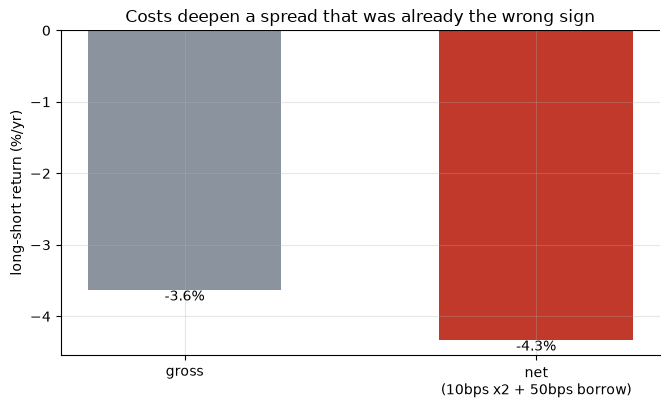

gross -3.6%/yr  ->  net -4.3%/yr


In [4]:
if HAVE_REAL:
    c = st.net_of_costs(PX, SH, frac=0.3, cost_bps=10.0, borrow_ann_bps=50.0)
    g, nv = c['gross_mean']*100, c['net_mean']*100
else:
    g, nv = R['gross'], R['net']
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(['gross','net\n(10bps x2 + 50bps borrow)'], [g, nv], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short return (%/yr)')
ax.set_title('Costs deepen a spread that was already the wrong sign')
for i,v in enumerate([g,nv]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f'gross {g:.1f}%/yr  ->  net {nv:.1f}%/yr')

Costs aren't the villain here — they just make a non-edge slightly more negative. The real problem is upstream: with 12-name baskets churning every year over 9 years, the spread is **inside its own error bar**, and you can't allocate capital to a number you can't distinguish from zero (let alone one pointing the wrong way).

## 7 · Going further 🚪

- **The real population.** The factor *works* in CRSP's full point-in-time cross-section — thousands of names, the small chronic diluters included, with a proper factor model. Our small survivor slice is the wrong instrument to see it, by design.
- **The split trap.** Try *not* split-adjusting the shares and watch every stock-split company (Apple 2020, NVIDIA, Tesla) suddenly look like a massive 'issuer' — a built-in demonstration of how a data glitch fabricates a factor.
- **The announcement cousin.** [Study 368 — Buyback-Drift](../../368-buyback-drift/) asks the *event* version: does a stock drift up after it *announces* a buyback? (Spoiler: also weak.)

*Think the issuance factor beats luck on a tradable basket? Capture it on a bigger, point-in-time universe, shuffle the labels, and show the real sort landing **outside** the cloud — then we'll talk.*